In [1]:
from pathlib import Path
import json
import pandas as pd

DATA_ROOT     = Path("../data/processed")
RAW_ROOT      = Path("../data/raw")
METADATA_PATH = DATA_ROOT / "metadata.csv"

# Sanity check
print(f"metadata.csv exists : {METADATA_PATH.exists()}")
print(f"raw data root exists: {RAW_ROOT.exists()}")
print(f"Raw participant dirs : {len(list(RAW_ROOT.iterdir()))}")


metadata.csv exists : True
raw data root exists: True
Raw participant dirs : 237


In [2]:
catalog = pd.read_csv(METADATA_PATH)

print(f"Shape: {catalog.shape}  ({catalog['fake_name'].nunique()} unique participants)")
print(f"\nColumns:\n{list(catalog.columns)}")
print(f"\nFirst 3 rows:")
catalog.head(3)


Shape: (1100, 15)  (236 unique participants)

Columns:
['sequence_uid', 'date', 'session_id', 'fake_name', 'act_id', 'location', 'script', 'participant_gender', 'participant_height_cm', 'participant_weight_kg', 'participant_bmi', 'participant_age_group', 'participant_ethnicity', 'gaze_type', 'has_gaze_data']

First 3 rows:


,sequence_uid,date,session_id,fake_name,act_id,location,script,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,gaze_type,has_gaze_data
0,20230628_s0_adriana_gonzalez_act0_e587mn,20230628,s0,adriana_gonzalez,act0,Loc_10,S11-Laundary,Male,177.0,81.0,25.9,25-30,Caucasian,personalized,True
1,20230628_s0_adriana_gonzalez_act1_2vshuw,20230628,s0,adriana_gonzalez,act1,Loc_10,S1-Relax_at_home,Male,177.0,81.0,25.9,25-30,Caucasian,personalized,True
2,20230628_s0_adriana_gonzalez_act4_rzxlmo,20230628,s0,adriana_gonzalez,act4,Loc_10,S7-Cooking,Male,177.0,81.0,25.9,25-30,Caucasian,personalized,True


In [3]:
def load_raw_json_fields(raw_root: Path) -> pd.DataFrame:
    records = []
    missing = []

    for json_path in sorted(raw_root.glob("*/*/metadata.json")):
        try:
            with open(json_path) as f:
                m = json.load(f)

            # Reconstruct sequence_uid the same way the CSV does
            uid = f"{m['date']}_{m['session_id']}_{m['fake_name']}_{m['act_id']}_{m['uid']}"

            records.append({
                "sequence_uid":          uid,
                "has_two_participants":  m.get("has_two_participants"),
                "pt2":                   m.get("pt2"),
                "action_duration_sec":   m.get("action_duration_sec"),
                "head_duration_sec":     m.get("head_duration_sec"),
            })
        except Exception as e:
            missing.append((str(json_path), str(e)))

    df = pd.DataFrame(records)
    print(f"JSONs parsed:  {len(df)}")
    print(f"Parse errors:  {len(missing)}")
    if missing:
        for path, err in missing:
            print(f"  ERROR {path}: {err}")
    return df

json_fields = load_raw_json_fields(RAW_ROOT)
json_fields.head(3)


JSONs parsed:  1100
Parse errors:  0


,sequence_uid,has_two_participants,pt2,action_duration_sec,head_duration_sec
0,20230628_s0_adriana_gonzalez_act0_e587mn,False,NaN,968.012,1198.474971
1,20230628_s0_adriana_gonzalez_act1_2vshuw,False,NaN,916.453,1033.734671
2,20230628_s0_adriana_gonzalez_act4_rzxlmo,False,NaN,932.051,1046.799244


In [4]:
catalog_enriched = catalog.merge(json_fields, on="sequence_uid", how="left")

matched = catalog_enriched["has_two_participants"].notna().sum()
print(f"Rows matched: {matched} / {len(catalog_enriched)}")
print(f"\nhas_two_participants breakdown:")
print(catalog_enriched["has_two_participants"].value_counts())


Rows matched: 1100 / 1100

has_two_participants breakdown:
has_two_participants
False    883
True     217
Name: count, dtype: int64


In [5]:
catalog_enriched["noise_sec"] = catalog_enriched["head_duration_sec"] - catalog_enriched["action_duration_sec"]
catalog_enriched["trim_start_sec"] = catalog_enriched["noise_sec"] / 2
catalog_enriched["trim_end_sec"]   = catalog_enriched["noise_sec"] / 2

print(catalog_enriched[["noise_sec", "trim_start_sec", "trim_end_sec"]].describe().round(1))


       noise_sec  trim_start_sec  trim_end_sec
count     1100.0          1100.0        1100.0
mean       169.9            85.0          85.0
std         94.8            47.4          47.4
min         81.5            40.7          40.7
25%        124.8            62.4          62.4
50%        151.1            75.5          75.5
75%        194.2            97.1          97.1
max       2554.7          1277.4        1277.4


In [7]:
# looking at the top 5 noisy data
catalog_enriched.nlargest(5, "noise_sec")[
    ["fake_name", "script", "noise_sec", "action_duration_sec", "head_duration_sec"]
]


,fake_name,script,noise_sec,action_duration_sec,head_duration_sec
625,julie_taylor,S3-Welcome_to_my_place,2554.724876,1002.306,3557.030876
427,erin_mccormick,S9-Making_a_mess,564.210056,762.311,1326.521056
494,heather_becker,S1-Relax_at_home,476.457109,935.717,1412.174109
104,angel_roberts,S3-Welcome_to_my_place,449.028532,950.081,1399.109532
775,michael_griffin,S11-Laundary,430.630859,860.196,1290.826859


In [9]:
mean_noise = catalog_enriched["noise_sec"].mean()
std_noise  = catalog_enriched["noise_sec"].std()
NOISE_FLAG_THRESHOLD_SEC = mean_noise + 3 * std_noise

catalog_enriched["noise_flag"] = catalog_enriched["noise_sec"] > NOISE_FLAG_THRESHOLD_SEC

print(f"Threshold: {NOISE_FLAG_THRESHOLD_SEC:.1f} sec  (mean + 3 SD)")
print(f"Sessions flagged: {catalog_enriched['noise_flag'].sum()}")
print(catalog_enriched[catalog_enriched["noise_flag"]][["fake_name", "script", "noise_sec"]])

Threshold: 454.2 sec  (mean + 3 SD)
Sessions flagged: 3
          fake_name                  script    noise_sec
427  erin_mccormick        S9-Making_a_mess   564.210056
494  heather_becker        S1-Relax_at_home   476.457109
625    julie_taylor  S3-Welcome_to_my_place  2554.724876


In [10]:
catalog_enriched.to_csv(METADATA_PATH, index=False)

print(f"Saved: {METADATA_PATH}")
print(f"Shape: {catalog_enriched.shape}")
print(f"New columns: {[c for c in catalog_enriched.columns if c not in catalog.columns]}")

Saved: ../data/processed/metadata.csv
Shape: (1100, 23)
New columns: ['has_two_participants', 'pt2', 'action_duration_sec', 'head_duration_sec', 'noise_sec', 'trim_start_sec', 'trim_end_sec', 'noise_flag']


In [11]:
# can be done using nymeria gaze tools with a slight modification in the toolkit code to include this flag in the dataframe
def get_sampling_rate(sequence_uid, data_root):
    path = data_root / "eye_gaze" / f"{sequence_uid}.csv"
    df = pd.read_csv(path, usecols=["tracking_timestamp_us"], nrows=50)
    median_interval_s = df["tracking_timestamp_us"].diff().dropna().median() / 1e6
    return round(1.0 / median_interval_s)

sampling_rates = {}
for uid in catalog_enriched["sequence_uid"]:
    sampling_rates[uid] = get_sampling_rate(uid, DATA_ROOT)

catalog_enriched["sampling_rate_hz"] = catalog_enriched["sequence_uid"].map(sampling_rates)

print(catalog_enriched["sampling_rate_hz"].value_counts())


sampling_rate_hz
10    1066
30      34
Name: count, dtype: int64


In [12]:
catalog_enriched.to_csv(METADATA_PATH, index=False)
print(f"Saved. Final columns: {list(catalog_enriched.columns)}")

Saved. Final columns: ['sequence_uid', 'date', 'session_id', 'fake_name', 'act_id', 'location', 'script', 'participant_gender', 'participant_height_cm', 'participant_weight_kg', 'participant_bmi', 'participant_age_group', 'participant_ethnicity', 'gaze_type', 'has_gaze_data', 'has_two_participants', 'pt2', 'action_duration_sec', 'head_duration_sec', 'noise_sec', 'trim_start_sec', 'trim_end_sec', 'noise_flag', 'sampling_rate_hz']


In [16]:
# display the enriched data
print(f"Shape: {catalog_enriched.shape}")
print(f"\nColumns and dtypes:")
print(catalog_enriched.dtypes)
print(f"\nFirst 3 rows:")
catalog_enriched.head(3)

Shape: (1100, 24)

Columns and dtypes:
sequence_uid                 str
date                       int64
session_id                   str
fake_name                    str
act_id                       str
location                     str
script                       str
participant_gender           str
participant_height_cm    float64
participant_weight_kg    float64
participant_bmi          float64
participant_age_group        str
participant_ethnicity        str
gaze_type                    str
has_gaze_data               bool
has_two_participants        bool
pt2                          str
action_duration_sec      float64
head_duration_sec        float64
noise_sec                float64
trim_start_sec           float64
trim_end_sec             float64
noise_flag                  bool
sampling_rate_hz           int64
dtype: object

First 3 rows:


,sequence_uid,date,session_id,fake_name,act_id,location,script,participant_gender,participant_height_cm,participant_weight_kg,...,has_gaze_data,has_two_participants,pt2,action_duration_sec,head_duration_sec,noise_sec,trim_start_sec,trim_end_sec,noise_flag,sampling_rate_hz
0,20230628_s0_adriana_gonzalez_act0_e587mn,20230628,s0,adriana_gonzalez,act0,Loc_10,S11-Laundary,Male,177.0,81.0,...,True,False,NaN,968.012,1198.474971,230.462971,115.231486,115.231486,False,10
1,20230628_s0_adriana_gonzalez_act1_2vshuw,20230628,s0,adriana_gonzalez,act1,Loc_10,S1-Relax_at_home,Male,177.0,81.0,...,True,False,NaN,916.453,1033.734671,117.281671,58.640835,58.640835,False,10
2,20230628_s0_adriana_gonzalez_act4_rzxlmo,20230628,s0,adriana_gonzalez,act4,Loc_10,S7-Cooking,Male,177.0,81.0,...,True,False,NaN,932.051,1046.799244,114.748244,57.374122,57.374122,False,10


In [1]:
from pathlib import Path
import pandas as pd
import nymeria_gaze_tools as ngt

DATA_ROOT = Path("../data/processed")

# Same filter block as analysis notebooks — gives us 809 sessions / 193 participants
catalog = ngt.load_metadata(data_root=DATA_ROOT)
catalog = catalog[catalog["sampling_rate_hz"] == 10]
catalog = catalog[catalog["noise_flag"] == False]
catalog = catalog[catalog["has_gaze_data"] == True]
catalog = catalog[catalog["has_two_participants"] == False]
catalog = (catalog
           .sort_values("date")
           .drop_duplicates(["fake_name", "script"])
           .reset_index(drop=True))

# One row per participant for demographics
participants = catalog.drop_duplicates("fake_name").reset_index(drop=True)
n = len(participants)
print(f"Unique participants: {n}\n")

for col, label in [
    ("participant_age_group",  "Age group"),
    ("participant_gender",     "Gender"),
    ("participant_ethnicity",  "Ethnicity"),
]:
    counts = participants[col].value_counts().sort_index()
    pct    = (counts / n * 100).round(1)
    print(f"--- {label} ---")
    for val, c, p in zip(counts.index, counts, pct):
        print(f"  {val:<30} {c:>4}  ({p}%)")
    print()


Unique participants: 193

--- Age group ---
  18-24                            39  (20.2%)
  25-30                            40  (20.7%)
  31-35                            36  (18.7%)
  36-40                            42  (21.8%)
  41-45                            18  (9.3%)
  46-50                            18  (9.3%)

--- Gender ---
  Female                           96  (49.7%)
  Male                             97  (50.3%)

--- Ethnicity ---
  African American                 23  (11.9%)
  Caucasian                        71  (36.8%)
  East Asian                       31  (16.1%)
  Hispanic                          9  (4.7%)
  Other/Mixed                       7  (3.6%)
  South Asian                      27  (14.0%)
  Southeast Asian                  25  (13.0%)



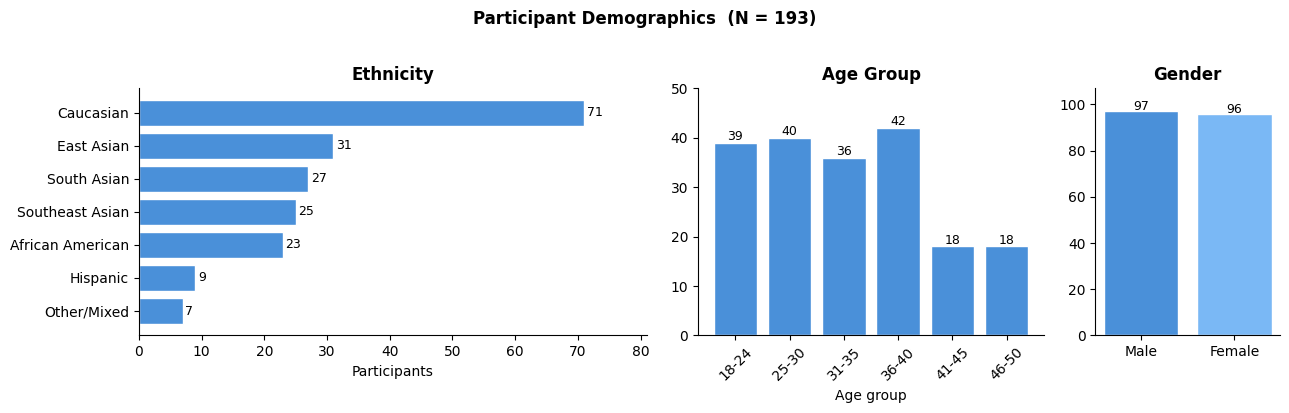

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4),
                         gridspec_kw={"width_ratios": [2.2, 1.5, 0.8]})

palette = "#4a90d9"

# --- Ethnicity (horizontal bars, sorted by count) ---
eth = (participants["participant_ethnicity"]
       .value_counts()
       .sort_values(ascending=True))
axes[0].barh(eth.index, eth.values, color=palette, edgecolor="white")
for i, v in enumerate(eth.values):
    axes[0].text(v + 0.4, i, str(v), va="center", fontsize=9)
axes[0].set_xlabel("Participants")
axes[0].set_title("Ethnicity", fontweight="bold")
axes[0].set_xlim(0, eth.max() + 10)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Age group (vertical bars, ordered) ---
age_order = ["18-24", "25-30", "31-35", "36-40", "41-45", "46-50"]
age = participants["participant_age_group"].value_counts().reindex(age_order)
axes[1].bar(age.index, age.values, color=palette, edgecolor="white")
for i, v in enumerate(age.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[1].set_xlabel("Age group")
axes[1].set_title("Age Group", fontweight="bold")
axes[1].set_ylim(0, age.max() + 8)
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].spines[["top", "right"]].set_visible(False)

# --- Gender (vertical bars) ---
gen = participants["participant_gender"].value_counts()
colors = ["#4a90d9", "#7ab8f5"]
axes[2].bar(gen.index, gen.values, color=colors, edgecolor="white")
for i, v in enumerate(gen.values):
    axes[2].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[2].set_title("Gender", fontweight="bold")
axes[2].set_ylim(0, gen.max() + 10)
axes[2].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Participant Demographics  (N = {n})", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demographics.png", dpi=150, bbox_inches="tight")
plt.show()
